# Supersonic axial ORC turbine stage — 1D meanline design

**KCORC Summer School 2026 — instructor development draft (v0.1)**  
Tuesday tutorial: real-fluid design of a single-stage axial impulse ORC turbine.

This notebook is a compact teaching implementation derived from the methodology in Jan Špale's dissertation and from the accompanying Python meanline model. It intentionally excludes genetic optimization, detailed MOC blade construction, CFD, structural design, and experimental calibration.

## Learning objectives

By the end of the notebook, students should be able to:

1. convert ORC cycle boundary conditions into turbine design inputs;
2. evaluate a real-fluid isentropic expansion;
3. identify the sonic throat of a convergent-divergent stator;
4. calculate throat and outlet flow areas;
5. construct absolute and relative velocity triangles;
6. estimate Euler work, empirical losses, mechanical power, and stage efficiency;
7. connect the thermodynamic design to first-order turbine geometry;
8. export a frozen design point for the off-design notebook.

> **Instructor note:** this is currently a fully working reference draft. A later student version can replace selected cells tagged `instructor-solution` with `TODO` blocks.


## 0. Environment

The workshop repository is intended to use the same `uv` workflow as the TESPy session.

```bash
uv sync
uv add numpy pandas scipy matplotlib CoolProp ipykernel
```

Open this notebook in VS Code or Jupyter and select the environment created by `uv`.

The student version uses the open-source **CoolProp** property backend. REFPROP can be used later as an instructor/reference comparison, but it is deliberately not required for participants.


In [15]:
from __future__ import annotations

from dataclasses import asdict, dataclass
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import CoolProp.CoolProp as CP
except ImportError as exc:
    raise ImportError(
        "CoolProp is required. In the repository terminal run: uv add CoolProp"
    ) from exc

plt.rcParams.update({
    "figure.figsize": (8.0, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)


## 1. Define the design problem

The cycle model supplies the quantities on the left. The quantities on the right are preliminary turbomachinery choices.

| Cycle boundary conditions | Preliminary stage choices |
|---|---|
| working fluid | rotational speed |
| inlet total pressure | mean diameter |
| inlet total temperature | stator outlet angle |
| outlet static pressure | rotor inlet/outlet metal angles |
| nominal mass flow | partial-admission fraction |
|  | chord and solidity |

The flow angles in this notebook are measured from the **circumferential/tangential direction toward the axial direction**, matching the original meanline-model convention.


In [16]:
@dataclass(frozen=True)
class DesignInputs:
    # Cycle boundary conditions
    fluid: str = "R1233zd(E)"
    p_in_Pa: float = 2.500e6
    T_in_K: float = 150.0 + 273.15
    p_out_Pa: float = 475.0e3
    m_dot_kg_s: float = 5.025

    # Stage design choices
    n_rpm: float = 3000.0
    D_mid_m: float = 0.500
    alpha_stator_deg: float = 11.5
    beta_rotor_in_deg: float = 23.0
    beta_rotor_out_acute_deg: float = 25.0
    partial_admission: float = 0.305
    chord_rotor_m: float = 0.025
    sigma_rotor: float = 1.0
    sigma_stator: float = 1.2
    rotor_height_allowance_m: float = 0.0003

    # Numerical setup
    nozzle_steps: int = 400


inp = DesignInputs()

pd.DataFrame(
    [(key, value) for key, value in asdict(inp).items()],
    columns=["Input", "Value"],
)


,Input,Value
0,fluid,R1233zd(E)
1,p_in_Pa,2500000.0
2,T_in_K,423.15
3,p_out_Pa,475000.0
4,m_dot_kg_s,5.025
5,n_rpm,3000.0
6,D_mid_m,0.5
7,alpha_stator_deg,11.5
8,beta_rotor_in_deg,23.0
9,beta_rotor_out_acute_deg,25.0


### Student checkpoint

Before running the model, estimate:

- the pressure ratio \(\Pi=p_{in}/p_{out}\);
- the order of magnitude of the isentropic velocity \(c_{is}=\sqrt{2\Delta h_{is}}\);
- whether a convergent-only or convergent-divergent stator is expected;
- whether 3000 rpm is high or low for a 0.5 m mean diameter.


## 2. Real-fluid state functions

CoolProp is used only through small helper functions. Keeping the property calls behind a narrow interface makes it easier to replace CoolProp with REFPROP later without rewriting the meanline equations.


In [17]:
def state_PT(p_Pa: float, T_K: float, fluid: str) -> dict[str, float | str]:
    '''Return a compact thermodynamic state from pressure and temperature.'''
    return {
        "p_Pa": float(p_Pa),
        "T_K": float(T_K),
        "h_J_kg": float(CP.PropsSI("H", "P", p_Pa, "T", T_K, fluid)),
        "s_J_kgK": float(CP.PropsSI("S", "P", p_Pa, "T", T_K, fluid)),
        "rho_kg_m3": float(CP.PropsSI("D", "P", p_Pa, "T", T_K, fluid)),
        "a_m_s": float(CP.PropsSI("A", "P", p_Pa, "T", T_K, fluid)),
        "phase": CP.PhaseSI("P", p_Pa, "T", T_K, fluid),
    }


def state_PS(p_Pa: float, s_J_kgK: float, fluid: str) -> dict[str, float]:
    '''Return a compact isentropic state from pressure and entropy.'''
    return {
        "p_Pa": float(p_Pa),
        "T_K": float(CP.PropsSI("T", "P", p_Pa, "S", s_J_kgK, fluid)),
        "h_J_kg": float(CP.PropsSI("H", "P", p_Pa, "S", s_J_kgK, fluid)),
        "rho_kg_m3": float(CP.PropsSI("D", "P", p_Pa, "S", s_J_kgK, fluid)),
        "a_m_s": float(CP.PropsSI("A", "P", p_Pa, "S", s_J_kgK, fluid)),
    }


def state_PH(p_Pa: float, h_J_kg: float, fluid: str) -> dict[str, float]:
    '''Return a compact state from pressure and specific enthalpy.'''
    return {
        "p_Pa": float(p_Pa),
        "T_K": float(CP.PropsSI("T", "P", p_Pa, "H", h_J_kg, fluid)),
        "h_J_kg": float(h_J_kg),
        "s_J_kgK": float(CP.PropsSI("S", "P", p_Pa, "H", h_J_kg, fluid)),
        "rho_kg_m3": float(CP.PropsSI("D", "P", p_Pa, "H", h_J_kg, fluid)),
        "a_m_s": float(CP.PropsSI("A", "P", p_Pa, "H", h_J_kg, fluid)),
    }


## 3. Overall isentropic expansion

The ideal stage enthalpy drop is evaluated at constant entropy:

\[
\Delta h_{is}=h_{in}-h_{out,is},
\qquad
c_{is}=\sqrt{2\Delta h_{is}}.
\]

The mean blade speed is

\[
U=\frac{\pi D_{mid}n}{60}.
\]

The ratio \(U/c_{is}\) is one of the most useful first indicators of whether the selected diameter and rotational speed are compatible with the available enthalpy drop.


In [18]:
state_in = state_PT(inp.p_in_Pa, inp.T_in_K, inp.fluid)
state_out_is = state_PS(inp.p_out_Pa, state_in["s_J_kgK"], inp.fluid)

pressure_ratio = inp.p_in_Pa / inp.p_out_Pa
dh_stage_is = state_in["h_J_kg"] - state_out_is["h_J_kg"]
c_is_stage = np.sqrt(2.0 * dh_stage_is)
U = np.pi * inp.D_mid_m * inp.n_rpm / 60.0
U_over_c_is = U / c_is_stage
Ma_out_is_stage = c_is_stage / state_out_is["a_m_s"]

stage_ideal_summary = pd.DataFrame([
    ("Inlet phase", state_in["phase"], "-"),
    ("Pressure ratio", pressure_ratio, "-"),
    ("Isentropic enthalpy drop", dh_stage_is / 1e3, "kJ/kg"),
    ("Isentropic velocity", c_is_stage, "m/s"),
    ("Mean blade speed", U, "m/s"),
    ("U/c_is", U_over_c_is, "-"),
    ("Ideal outlet Mach estimate", Ma_out_is_stage, "-"),
], columns=["Quantity", "Value", "Unit"])

stage_ideal_summary


,Quantity,Value,Unit
0,Inlet phase,gas,-
1,Pressure ratio,5.263158,-
2,Isentropic enthalpy drop,31.673709,kJ/kg
3,Isentropic velocity,251.689131,m/s
4,Mean blade speed,78.539816,m/s
5,U/c_is,0.312051,-
6,Ideal outlet Mach estimate,1.774098,-


## 4. Quasi-1D stator expansion and sonic throat

The pressure interval is discretized. At every pressure, an isentropic state is evaluated and the local velocity follows from the steady-flow energy equation:

\[
c_{is}(p)=\sqrt{2\left(h_{in}-h_{is}(p)\right)},
\qquad
Ma_{is}(p)=\frac{c_{is}(p)}{a_{is}(p)}.
\]

The sampled state nearest \(Ma=1\) is used as the throat.

The original design method introduces a stator velocity coefficient \(\phi_s\). In the simplified teaching model, losses are applied primarily in the supersonic part of the expansion:

\[
h_{act}(p)=h_{is,*}-\phi_s^2\left(h_{is,*}-h_{is}(p)\right),
\qquad Ma_{is}\ge 1.
\]

This is a reduced loss treatment, not a substitute for a viscous nozzle calculation.


In [19]:
def stator_velocity_coefficient(Ma_out_is: float) -> float:
    '''Semi-empirical stator velocity coefficient used in the source model.'''
    loss_fraction = (
        0.0029 * Ma_out_is**3
        - 0.0502 * Ma_out_is**2
        + 0.2241 * Ma_out_is
        - 0.0877
    )
    return float(np.sqrt(np.clip(1.0 - loss_fraction, 1e-6, 1.0)))


def quasi_1d_stator(inp: DesignInputs, state_in: dict[str, float | str]) -> tuple[pd.DataFrame, dict[str, float]]:
    p_path = np.linspace(inp.p_in_Pa, inp.p_out_Pa, inp.nozzle_steps)
    s_in = float(state_in["s_J_kgK"])
    h_in = float(state_in["h_J_kg"])

    h_is = np.empty_like(p_path)
    T_is = np.empty_like(p_path)
    rho_is = np.empty_like(p_path)
    a_is = np.empty_like(p_path)

    for i, p_i in enumerate(p_path):
        st = state_PS(float(p_i), s_in, inp.fluid)
        h_is[i] = st["h_J_kg"]
        T_is[i] = st["T_K"]
        rho_is[i] = st["rho_kg_m3"]
        a_is[i] = st["a_m_s"]

    c_is = np.sqrt(np.maximum(2.0 * (h_in - h_is), 0.0))
    Ma_is = np.divide(c_is, a_is, out=np.zeros_like(c_is), where=a_is > 0.0)

    if np.nanmax(Ma_is) < 1.0:
        raise ValueError(
            "The specified expansion does not reach Ma=1. "
            "A convergent-divergent stator is not indicated by this model."
        )

    throat_index = int(np.nanargmin(np.abs(Ma_is - 1.0)))
    phi_s = stator_velocity_coefficient(float(Ma_is[-1]))

    h_act = h_is.copy()
    supersonic = np.arange(len(p_path)) >= throat_index
    h_act[supersonic] = h_is[throat_index] - phi_s**2 * (
        h_is[throat_index] - h_is[supersonic]
    )

    T_act = np.empty_like(p_path)
    rho_act = np.empty_like(p_path)
    a_act = np.empty_like(p_path)
    s_act = np.empty_like(p_path)

    for i, (p_i, h_i) in enumerate(zip(p_path, h_act)):
        st = state_PH(float(p_i), float(h_i), inp.fluid)
        T_act[i] = st["T_K"]
        rho_act[i] = st["rho_kg_m3"]
        a_act[i] = st["a_m_s"]
        s_act[i] = st["s_J_kgK"]

    c_act = np.sqrt(np.maximum(2.0 * (h_in - h_act), 0.0))
    Ma_act = np.divide(c_act, a_act, out=np.zeros_like(c_act), where=a_act > 0.0)

    path = pd.DataFrame({
        "p_Pa": p_path,
        "pressure_ratio_local": p_path / inp.p_out_Pa,
        "T_is_K": T_is,
        "rho_is_kg_m3": rho_is,
        "h_is_J_kg": h_is,
        "a_is_m_s": a_is,
        "c_is_m_s": c_is,
        "Ma_is": Ma_is,
        "T_act_K": T_act,
        "rho_act_kg_m3": rho_act,
        "h_act_J_kg": h_act,
        "s_act_J_kgK": s_act,
        "a_act_m_s": a_act,
        "c_act_m_s": c_act,
        "Ma_act": Ma_act,
    })

    scalars = {
        "throat_index": throat_index,
        "phi_stator": phi_s,
        "p_throat_Pa": float(p_path[throat_index]),
        "T_throat_K": float(T_is[throat_index]),
        "rho_throat_kg_m3": float(rho_is[throat_index]),
        "a_throat_m_s": float(a_is[throat_index]),
        "c_throat_m_s": float(c_is[throat_index]),
        "Ma_throat": float(Ma_is[throat_index]),
        "h_nozzle_out_J_kg": float(h_act[-1]),
        "T_nozzle_out_K": float(T_act[-1]),
        "rho_nozzle_out_kg_m3": float(rho_act[-1]),
        "a_nozzle_out_m_s": float(a_act[-1]),
        "c_nozzle_out_m_s": float(c_act[-1]),
        "Ma_nozzle_out": float(Ma_act[-1]),
        "Ma_nozzle_out_is": float(Ma_is[-1]),
    }
    return path, scalars


nozzle_path, nozzle = quasi_1d_stator(inp, state_in)

pd.DataFrame([
    ("Stator velocity coefficient", nozzle["phi_stator"], "-"),
    ("Throat pressure", nozzle["p_throat_Pa"] / 1e3, "kPa"),
    ("Throat temperature", nozzle["T_throat_K"] - 273.15, "degC"),
    ("Sampled throat Mach", nozzle["Ma_throat"], "-"),
    ("Ideal stator-outlet Mach", nozzle["Ma_nozzle_out_is"], "-"),
    ("Loss-adjusted outlet Mach", nozzle["Ma_nozzle_out"], "-"),
    ("Loss-adjusted outlet velocity", nozzle["c_nozzle_out_m_s"], "m/s"),
], columns=["Quantity", "Value", "Unit"])


,Quantity,Value,Unit
0,Stator velocity coefficient,0.912103,-
1,Throat pressure,1606.766917,kPa
2,Throat temperature,127.098661,degC
3,Sampled throat Mach,0.999509,-
4,Ideal stator-outlet Mach,1.774098,-
5,Loss-adjusted outlet Mach,1.640563,-
6,Loss-adjusted outlet velocity,235.157643,m/s


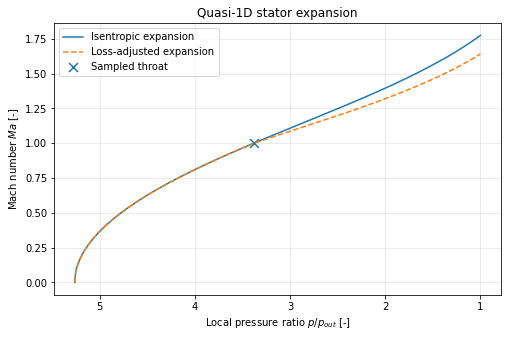

In [20]:
fig, ax = plt.subplots()
ax.plot(
    nozzle_path["pressure_ratio_local"],
    nozzle_path["Ma_is"],
    label="Isentropic expansion",
)
ax.plot(
    nozzle_path["pressure_ratio_local"],
    nozzle_path["Ma_act"],
    linestyle="--",
    label="Loss-adjusted expansion",
)
ax.scatter(
    nozzle["p_throat_Pa"] / inp.p_out_Pa,
    nozzle["Ma_throat"],
    marker="x",
    s=80,
    label="Sampled throat",
)
ax.set_xlabel(r"Local pressure ratio $p/p_{out}$ [-]")
ax.set_ylabel(r"Mach number $Ma$ [-]")
ax.invert_xaxis()
ax.legend()
ax.set_title("Quasi-1D stator expansion")
plt.show()


### Student task — interpretation

Explain why the loss-adjusted Mach number is lower than the isentropic value even though both calculations use the same inlet state and outlet pressure. Which quantity increases because of the irreversibility?


## 5. Nozzle flow areas

For the teaching model, the effective flow area follows directly from continuity:

\[
A=\frac{\dot m}{\rho c}.
\]

Three areas are useful:

- \(A^*\): sonic throat area;
- \(A_{out,is}\): outlet area based on the ideal isentropic state;
- \(A_{out,act}\): outlet area required by the loss-adjusted state.

The geometric area used for manufacturing may later include discharge, blockage, boundary-layer, and trailing-edge corrections. These corrections are deliberately postponed in this introductory notebook.


In [21]:
throat_row = nozzle_path.iloc[int(nozzle["throat_index"])]
outlet_row = nozzle_path.iloc[-1]

A_throat_m2 = inp.m_dot_kg_s / (
    throat_row["rho_is_kg_m3"] * throat_row["c_is_m_s"]
)
A_outlet_is_m2 = inp.m_dot_kg_s / (
    outlet_row["rho_is_kg_m3"] * outlet_row["c_is_m_s"]
)
A_outlet_act_m2 = inp.m_dot_kg_s / (
    outlet_row["rho_act_kg_m3"] * outlet_row["c_act_m_s"]
)

A_ratio_is = A_outlet_is_m2 / A_throat_m2
A_ratio_act = A_outlet_act_m2 / A_throat_m2

area_summary = pd.DataFrame([
    ("Sonic throat area", A_throat_m2 * 1e6, "mm^2"),
    ("Ideal outlet area", A_outlet_is_m2 * 1e6, "mm^2"),
    ("Loss-adjusted outlet area", A_outlet_act_m2 * 1e6, "mm^2"),
    ("Ideal area ratio", A_ratio_is, "-"),
    ("Loss-adjusted area ratio", A_ratio_act, "-"),
], columns=["Quantity", "Value", "Unit"])

area_summary


,Quantity,Value,Unit
0,Sonic throat area,463.233328,mm^2
1,Ideal outlet area,848.723165,mm^2
2,Loss-adjusted outlet area,924.273245,mm^2
3,Ideal area ratio,1.832172,-
4,Loss-adjusted area ratio,1.995265,-


## 6. First-order stator geometry and partial admission

The current model sizes the nozzle/blade height from the axial component of the stator-exit velocity:

\[
h_s=\frac{\dot m}{\rho_1 c_{1a}\,e\,\pi D_{mid}},
\qquad
c_{1a}=c_1\sin\alpha_1.
\]

This equation exposes an important design trade-off: for fixed mass flow and diameter, reducing the admitted circumferential fraction \(e\) increases the required blade height.


In [22]:
alpha_1_rad = np.radians(inp.alpha_stator_deg)
c1 = nozzle["c_nozzle_out_m_s"]
c1a = c1 * np.sin(alpha_1_rad)
c1u = c1 * np.cos(alpha_1_rad)

eps = float(np.clip(inp.partial_admission, 1e-6, 1.0))
h_nozzle_m = inp.m_dot_kg_s / (
    nozzle["rho_nozzle_out_kg_m3"]
    * c1a
    * eps
    * np.pi
    * inp.D_mid_m
)
h_rotor_m = h_nozzle_m + inp.rotor_height_allowance_m

chord_stator_ax_m = 1.25 * inp.chord_rotor_m
pitch_stator_m = chord_stator_ax_m / inp.sigma_stator
n_nozzles = max(1, int(round(eps * np.pi * inp.D_mid_m / pitch_stator_m)))
eps_effective = n_nozzles * pitch_stator_m / (np.pi * inp.D_mid_m)

b_total_throat_m = A_throat_m2 / h_nozzle_m
b_total_outlet_m = A_outlet_act_m2 / h_nozzle_m
b_nozzle_throat_m = b_total_throat_m / n_nozzles
b_nozzle_outlet_m = b_total_outlet_m / n_nozzles

pd.DataFrame([
    ("Requested partial admission", eps, "-"),
    ("Integer nozzle count", n_nozzles, "-"),
    ("Effective partial admission", eps_effective, "-"),
    ("Nozzle blade height", h_nozzle_m * 1e3, "mm"),
    ("Rotor blade height", h_rotor_m * 1e3, "mm"),
    ("Single-nozzle throat width", b_nozzle_throat_m * 1e3, "mm"),
    ("Single-nozzle outlet width", b_nozzle_outlet_m * 1e3, "mm"),
], columns=["Quantity", "Value", "Unit"])


,Quantity,Value,Unit
0,Requested partial admission,0.305000,-
1,Integer nozzle count,18.000000,-
2,Effective partial admission,0.298416,-
3,Nozzle blade height,9.676657,mm
4,Rotor blade height,9.976657,mm
5,Single-nozzle throat width,2.659512,mm
6,Single-nozzle outlet width,5.306431,mm


## 7. Rotor velocity triangle and velocity loss

At the rotor inlet:

\[
w_{1a}=c_{1a},
\qquad
w_{1u}=c_{1u}-U.
\]

The relative outlet speed is reduced with a semi-empirical rotor velocity coefficient \(\phi_r\). A sector filling/emptying factor \(K_s\) is included as a simple partial-admission correction:

\[
w_2=-w_1\phi_r K_s.
\]

This is an engineering reduced-order model. The correlation and its validity range must be discussed rather than treated as a universal physical law.


In [23]:
def rotor_velocity_coefficient(
    theta_deg: float,
    Ma1_rel: float,
    blade_height_m: float,
    chord_m: float,
) -> tuple[float, float]:
    '''Return the base and aspect-ratio-corrected rotor velocity coefficients.'''
    phi_base = (
        0.957
        - 0.000362 * theta_deg
        - 0.0258 * Ma1_rel
        + 0.00000639 * theta_deg**2
        + 0.0674 * Ma1_rel**2
        - 0.0000000753 * theta_deg**3
        - 0.043 * Ma1_rel**3
        - 0.000238 * theta_deg * Ma1_rel
        + 0.00000145 * theta_deg**2 * Ma1_rel
        + 0.0000425 * theta_deg * Ma1_rel**2
    )

    k1 = 2.0
    k2 = 0.65
    inside = 1.0 - ((1.0 - phi_base**2) / k1) * (
        1.0 + (k1 - 1.0) * (blade_height_m / chord_m) ** (-k2)
    )
    phi_corrected = float(np.sqrt(max(inside, 1e-12)))
    return float(phi_base), phi_corrected


w1a = c1a
w1u = c1u - U
w1 = float(np.hypot(w1a, w1u))
Ma1_rel = w1 / nozzle["a_nozzle_out_m_s"]
beta1_flow_deg = float(np.degrees(np.arctan2(w1a, w1u)))

beta2_deg = 180.0 - inp.beta_rotor_out_acute_deg
theta_deg = beta2_deg - inp.beta_rotor_in_deg

phi_rotor_base, phi_rotor = rotor_velocity_coefficient(
    theta_deg,
    Ma1_rel,
    h_rotor_m,
    inp.chord_rotor_m,
)

pitch_rotor_m = inp.chord_rotor_m / inp.sigma_rotor
n_rotor_blades = max(1, int(round(np.pi * inp.D_mid_m / pitch_rotor_m)))
f_active_m = eps * np.pi * inp.D_mid_m
K_sector = float(np.clip(1.0 - pitch_rotor_m / f_active_m, 0.0, 1.0))

w2_signed = -w1 * phi_rotor * K_sector
w2a = w2_signed * (-np.sin(np.radians(beta2_deg)))
w2u = w2_signed * (-np.cos(np.radians(beta2_deg)))

c2a = w2a
c2u = w2u + U
c2 = float(np.hypot(c2a, c2u))
alpha2_deg = float(np.degrees(np.arctan2(c2a, c2u)))

dh_rotor_loss_J_kg = (w1**2 - w2_signed**2) / 2.0
h_rotor_out_J_kg = nozzle["h_nozzle_out_J_kg"] + dh_rotor_loss_J_kg
state_rotor_out = state_PH(inp.p_out_Pa, h_rotor_out_J_kg, inp.fluid)

pd.DataFrame([
    ("Rotor inlet relative speed", w1, "m/s"),
    ("Rotor inlet relative Mach", Ma1_rel, "-"),
    ("Rotor inlet flow angle", beta1_flow_deg, "deg"),
    ("Specified rotor inlet metal angle", inp.beta_rotor_in_deg, "deg"),
    ("Rotor total deflection parameter", theta_deg, "deg"),
    ("Base rotor velocity coefficient", phi_rotor_base, "-"),
    ("Corrected rotor velocity coefficient", phi_rotor, "-"),
    ("Sector coefficient", K_sector, "-"),
    ("Rotor outlet absolute axial velocity", c2a, "m/s"),
    ("Rotor outlet absolute tangential velocity", c2u, "m/s"),
    ("Rotor outlet absolute angle", alpha2_deg, "deg"),
], columns=["Quantity", "Value", "Unit"])


,Quantity,Value,Unit
0,Rotor inlet relative speed,158.967589,m/s
1,Rotor inlet relative Mach,1.109027,-
2,Rotor inlet flow angle,17.152805,deg
3,Specified rotor inlet metal angle,23.000000,deg
4,Rotor total deflection parameter,132.000000,deg
5,Base rotor velocity coefficient,0.843077,-
6,Corrected rotor velocity coefficient,0.769840,-
7,Sector coefficient,0.947818,-
8,Rotor outlet absolute axial velocity,49.021012,m/s
9,Rotor outlet absolute tangential velocity,-26.586084,m/s


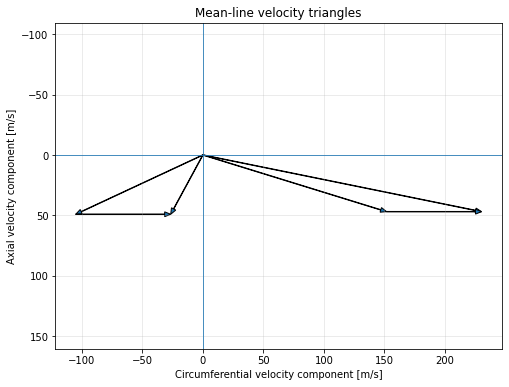

In [24]:
def plot_velocity_triangles(
    c1a: float,
    c1u: float,
    w1a: float,
    w1u: float,
    c2a: float,
    c2u: float,
    w2a: float,
    w2u: float,
    U: float,
) -> None:
    fig, ax = plt.subplots(figsize=(8, 6))

    vectors = [
        (0.0, 0.0, c1u, c1a, r"$c_1$"),
        (0.0, 0.0, w1u, w1a, r"$w_1$"),
        (w1u, w1a, U, 0.0, r"$U$ at inlet"),
        (0.0, 0.0, c2u, c2a, r"$c_2$"),
        (0.0, 0.0, w2u, w2a, r"$w_2$"),
        (w2u, w2a, U, 0.0, r"$U$ at outlet"),
    ]

    for x0, y0, dx, dy, label in vectors:
        ax.arrow(
            x0,
            y0,
            dx,
            dy,
            width=0.35,
            head_width=4.0,
            head_length=5.0,
            length_includes_head=True,
            label=label,
        )

    ax.axvline(0.0, linewidth=0.8)
    ax.axhline(0.0, linewidth=0.8)
    ax.set_xlabel("Circumferential velocity component [m/s]")
    ax.set_ylabel("Axial velocity component [m/s]")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title("Mean-line velocity triangles")
    ax.invert_yaxis()
    plt.show()


plot_velocity_triangles(c1a, c1u, w1a, w1u, c2a, c2u, w2a, w2u, U)


### Student task — incidence and exit swirl

1. Compare the calculated rotor-inlet **flow angle** with the specified rotor-inlet **metal angle**. What does the difference represent?
2. Is \(c_{2u}=0\) always the efficiency optimum?
3. What could a non-zero \(c_{2u}\) mean for a downstream turbine stage or connecting duct?


## 8. Power, losses, and efficiency

The aerodynamic power follows Euler's turbine equation:

\[
P_{aero}=\dot m U(c_{1u}-c_{2u}).
\]

Two additional empirical power losses are retained from the development model:

- disk/windage friction;
- partial-admission/ventilation loss.

For transparency, both partial-admission estimates are calculated and the conservative maximum is used. Their coefficients are empirical and should be challenged during the tutorial.


In [25]:
P_aero_W = inp.m_dot_kg_s * U * (c1u - c2u)

rho2 = state_rotor_out["rho_kg_m3"]
P_fric_W = 0.01 * (inp.n_rpm / 60.0) ** 3 * inp.D_mid_m**5 * rho2

P_pa_legacy_W = (
    (1.0 - eps)
    * rho2
    * (inp.n_rpm / 60.0) ** 3
    * inp.D_mid_m**4
    * 3.8
    * h_rotor_m
)

Kp_unenclosed = 3.63
enclosure_factor = 0.4
Kp = Kp_unenclosed * enclosure_factor
P_pa_pumping_W = (
    Kp
    * rho2
    * U**3
    * h_rotor_m
    * inp.D_mid_m**4
    * (1.0 - eps)
)

P_partial_admission_W = max(P_pa_legacy_W, P_pa_pumping_W)
P_mech_W = P_aero_W - P_fric_W - P_partial_admission_W
eta_turb = P_mech_W / (inp.m_dot_kg_s * dh_stage_is)

h_out_eta_J_kg = state_in["h_J_kg"] - eta_turb * dh_stage_is
state_out_eta = state_PH(inp.p_out_Pa, h_out_eta_J_kg, inp.fluid)
degree_of_reaction_proxy = dh_rotor_loss_J_kg / dh_stage_is

performance_summary = pd.DataFrame([
    ("Aerodynamic power", P_aero_W / 1e3, "kW"),
    ("Disk/windage loss", P_fric_W / 1e3, "kW"),
    ("PA loss — legacy correlation", P_pa_legacy_W / 1e3, "kW"),
    ("PA loss — pumping estimate", P_pa_pumping_W / 1e3, "kW"),
    ("PA loss used", P_partial_admission_W / 1e3, "kW"),
    ("Mechanical power", P_mech_W / 1e3, "kW"),
    ("Stage isentropic efficiency", eta_turb, "-"),
    ("Efficiency-based outlet temperature", state_out_eta["T_K"] - 273.15, "degC"),
    ("Rotor loss/reaction proxy", degree_of_reaction_proxy, "-"),
], columns=["Quantity", "Value", "Unit"])

performance_summary


,Quantity,Value,Unit
0,Aerodynamic power,101.437307,kW
1,Disk/windage loss,0.881273,kW
2,PA loss — legacy correlation,4.644019,kW
3,PA loss — pumping estimate,6.877595,kW
4,PA loss used,6.877595,kW
5,Mechanical power,93.678439,kW
6,Stage isentropic efficiency,0.588579,-
7,Efficiency-based outlet temperature,95.484383,degC
8,Rotor loss/reaction proxy,0.186530,-


## 9. Consolidated design summary

The expected order of magnitude for the supplied design point is approximately:

- ideal stator-outlet Mach: **1.7–1.8**;
- loss-adjusted stator-outlet Mach: **about 1.6**;
- nozzle height: **about 10 mm**;
- mechanical power: **about 90 kW**;
- stage efficiency: **about 0.55–0.60**.

Small deviations from the development model are expected because this notebook uses CoolProp rather than the original REFPROP backend and contains a deliberately reduced teaching implementation.


In [26]:
D_hub_m = inp.D_mid_m - h_rotor_m
D_tip_m = inp.D_mid_m + h_rotor_m

summary_rows = [
    ("fluid", inp.fluid, "-"),
    ("pressure_ratio", pressure_ratio, "-"),
    ("dh_stage_is", dh_stage_is / 1e3, "kJ/kg"),
    ("U_over_c_is", U_over_c_is, "-"),
    ("Ma_nozzle_out_is", nozzle["Ma_nozzle_out_is"], "-"),
    ("Ma_nozzle_out", nozzle["Ma_nozzle_out"], "-"),
    ("A_throat", A_throat_m2 * 1e6, "mm^2"),
    ("A_outlet_actual", A_outlet_act_m2 * 1e6, "mm^2"),
    ("A_ratio_actual", A_ratio_act, "-"),
    ("h_nozzle", h_nozzle_m * 1e3, "mm"),
    ("h_rotor", h_rotor_m * 1e3, "mm"),
    ("D_hub", D_hub_m * 1e3, "mm"),
    ("D_tip", D_tip_m * 1e3, "mm"),
    ("n_nozzles", n_nozzles, "-"),
    ("n_rotor_blades", n_rotor_blades, "-"),
    ("c1a", c1a, "m/s"),
    ("c1u", c1u, "m/s"),
    ("c2a", c2a, "m/s"),
    ("c2u", c2u, "m/s"),
    ("P_mech", P_mech_W / 1e3, "kW"),
    ("eta_turb", eta_turb, "-"),
]

design_summary = pd.DataFrame(summary_rows, columns=["Quantity", "Value", "Unit"])
design_summary


,Quantity,Value,Unit
0,fluid,R1233zd(E),-
1,pressure_ratio,5.263158,-
2,dh_stage_is,31.673709,kJ/kg
3,U_over_c_is,0.312051,-
4,Ma_nozzle_out_is,1.774098,-
5,Ma_nozzle_out,1.640563,-
6,A_throat,463.233328,mm^2
7,A_outlet_actual,924.273245,mm^2
8,A_ratio_actual,1.995265,-
9,h_nozzle,9.676657,mm


## 10. Export the frozen design

The next notebook must evaluate **one fixed machine**. Therefore, the design-point geometry is exported and must not be resized at every off-design operating point.

The exported JSON separates:

- cycle/design inputs;
- thermodynamic design-point results;
- frozen geometry;
- design-point performance.


In [27]:
design_export = {
    "model_version": "kcorc-teaching-draft-0.1",
    "inputs": asdict(inp),
    "thermodynamics": {
        "pressure_ratio_design": pressure_ratio,
        "h_in_J_kg": state_in["h_J_kg"],
        "s_in_J_kgK": state_in["s_J_kgK"],
        "dh_stage_is_J_kg": dh_stage_is,
        "c_is_stage_m_s": c_is_stage,
        "U_design_m_s": U,
        "U_over_c_is_design": U_over_c_is,
    },
    "nozzle": {
        "phi_stator_design": nozzle["phi_stator"],
        "p_throat_Pa": nozzle["p_throat_Pa"],
        "T_throat_K": nozzle["T_throat_K"],
        "Ma_out_is_design": nozzle["Ma_nozzle_out_is"],
        "Ma_out_design": nozzle["Ma_nozzle_out"],
        "A_throat_m2": A_throat_m2,
        "A_outlet_is_m2": A_outlet_is_m2,
        "A_outlet_act_m2": A_outlet_act_m2,
        "A_ratio_is": A_ratio_is,
        "A_ratio_act": A_ratio_act,
    },
    "geometry": {
        "D_mid_m": inp.D_mid_m,
        "D_hub_m": D_hub_m,
        "D_tip_m": D_tip_m,
        "h_nozzle_m": h_nozzle_m,
        "h_rotor_m": h_rotor_m,
        "partial_admission": eps,
        "partial_admission_effective": eps_effective,
        "alpha_stator_deg": inp.alpha_stator_deg,
        "beta_rotor_in_deg": inp.beta_rotor_in_deg,
        "beta_rotor_out_acute_deg": inp.beta_rotor_out_acute_deg,
        "chord_rotor_m": inp.chord_rotor_m,
        "pitch_rotor_m": pitch_rotor_m,
        "sigma_rotor": inp.sigma_rotor,
        "pitch_stator_m": pitch_stator_m,
        "sigma_stator": inp.sigma_stator,
        "n_nozzles": n_nozzles,
        "n_rotor_blades": n_rotor_blades,
        "K_sector": K_sector,
    },
    "performance": {
        "m_dot_design_kg_s": inp.m_dot_kg_s,
        "n_design_rpm": inp.n_rpm,
        "P_aero_design_W": P_aero_W,
        "P_fric_design_W": P_fric_W,
        "P_partial_admission_design_W": P_partial_admission_W,
        "P_mech_design_W": P_mech_W,
        "eta_turb_design": eta_turb,
        "h_out_design_J_kg": h_out_eta_J_kg,
        "T_out_design_K": state_out_eta["T_K"],
    },
}

with (OUTPUT_DIR / "design_point.json").open("w", encoding="utf-8") as file:
    json.dump(design_export, file, indent=2)

nozzle_path.to_csv(OUTPUT_DIR / "design_nozzle_expansion.csv", index=False)
design_summary.to_csv(OUTPUT_DIR / "design_summary.csv", index=False)

print("Created:")
print(" -", OUTPUT_DIR / "design_point.json")
print(" -", OUTPUT_DIR / "design_nozzle_expansion.csv")
print(" -", OUTPUT_DIR / "design_summary.csv")


Created:
 - outputs\design_point.json
 - outputs\design_nozzle_expansion.csv
 - outputs\design_summary.csv


## 11. Short sensitivity exercise

Change **one parameter at a time** and explain both the thermodynamic and geometric consequence:

1. increase the pressure ratio;
2. reduce the rotational speed;
3. reduce the mean diameter;
4. reduce partial admission;
5. increase the stator outlet angle.

For each change, track at least:

\[
Ma_{out},\quad U/c_{is},\quad h_s,\quad c_{2u},\quad P_{mech},\quad \eta_{turb}.
\]

Do not optimize yet. The objective is to develop physical intuition before introducing automated search methods.


## Model limitations to retain in the final lesson

- The loss correlations are empirical and should be presented with their assumptions and uncertainty.
- The quasi-1D stator treatment does not resolve shocks, boundary layers, trailing-edge wakes, or non-uniform exit flow.
- The rotor model is a mean-line momentum/velocity-coefficient model, not a blade-to-blade solution.
- The partial-admission treatment is reduced order.
- The geometric area calculated from continuity is an **effective flow area** unless discharge/blockage corrections are introduced.
- CoolProp and REFPROP results can differ, especially close to the saturation boundary.
- A fixed-geometry off-design model must not redesign the nozzle height or throat area at every operating point.
